# Estimating a Sequential Search Model

A first course, from Weitzman’s rule to a working estimator

## Who this is for

You know maximum likelihood, discrete choice, and simulation-based estimation. You have never estimated a search model. By the end you will have written one from scratch, understood why the obvious approach fails, and seen where each extension in the literature comes from.

Everything runs in base R. No packages.

## 1. Why a choice model is not enough

In a standard discrete choice model, a consumer sees $J$ alternatives, knows the utility of each, and picks the best. The likelihood is $\Pr(u_{iy} \ge u_{ij}\ \forall j)$, and with the right distributional assumption it has a closed form.

Now suppose the consumer does not know the utilities. She sees something about each alternative, and must pay a cost to learn the rest. She inspects a few, then buys one of the ones she inspected. You observe **which alternatives she inspected, in what order, how many, and which she bought.**

A choice model cannot use most of that. It has no notion of inspection, so it cannot explain why she opened three alternatives rather than one, why she opened *those* three, or why she stopped when she did. Worse, it will attribute her purchase to a comparison she never made — against alternatives she never looked at.

The search model’s job is to explain all four margins at once: **which, in what order, how many, and which bought.**

## 2. Pandora’s boxes

> **The problem Weitzman ([1979](#ref-Weitzman_1979)) solved**
>
> There are $J$ closed boxes. Box $j$ contains a prize $u_j$ drawn from a known distribution $F_j$. Opening it costs $c_j$. You may open boxes in any order, stopping whenever you like, and you keep the best prize you have seen. What is the optimal policy?

This looks like it should require dynamic programming over the set of opened boxes — an exponentially large state space. Weitzman’s result is that it does not.

### The reservation value

For each box, define $z_j$ as the prize level that would make you exactly indifferent about opening it:

$$
\mathbb{E}\left[\max(u_j - z_j,\ 0)\right] \;=\; c_j .
$$

Read the left side as *the expected gain from opening box $j$ when you already hold $z_j$ in hand*. If you hold more than $z_j$, opening is not worth it. If you hold less, it is.

> **The result that makes everything tractable**
>
> $z_j$ depends **only on box $j$’s own distribution and its own cost**. It does not depend on what else is available, on how many boxes there are, or on what you have already found.
>
> That is what collapses the dynamic program. Each box gets a single number, computed in isolation, once and for all.

**What the result assumes.** Three conditions are doing the work, and only the third is ever seriously at risk.

1.  You know each $F_j$ before opening anything. You draw *from* the distribution; you do not learn *about* it. (Relaxing this is the search-and-learning literature, a different model.)
2.  One inspection reveals $u_j$ exactly and permanently, and you may return and take any prize already seen — **full revelation and free recall**.
3.  $u_j$ is **independent across $j$**.

Independence is what reduces the state to (best prize in hand, set still unopened). Under correlated prizes, opening box 1 tells you something about box 2, so the realizations of everything opened enter your beliefs about everything unopened, $z_j$ stops being a fixed number computable in isolation, and Weitzman’s rules are no longer optimal. Note this is a statement about the *searcher’s* problem: §11.4 introduces heterogeneity, which induces correlation across alternatives from the *analyst’s* point of view while leaving each consumer’s own problem independent. The two are easy to conflate and are not the same thing.

### Working out $z$ for the normal case

Let $u_j \sim N(\delta_j, \sigma^2)$. Substituting $t = (u-\delta_j)/\sigma$ and $\zeta_j = (z_j - \delta_j)/\sigma$:

$$
\mathbb{E}\left[\max(u_j - z_j, 0)\right]
= \sigma \int_{\zeta_j}^{\infty} (t - \zeta_j)\,\phi(t)\,dt
= \sigma\Big[\underbrace{\phi(\zeta_j) - \zeta_j\big(1 - \Phi(\zeta_j)\big)}_{\displaystyle g(\zeta_j)}\Big].
$$

So the reservation value is

$$
z_j = \delta_j + \zeta_j\,\sigma, \qquad \text{where } g(\zeta_j) = c_j/\sigma .
$$

$g$ is strictly decreasing, so it inverts. Cheap search means a large $\zeta$ and a reservation value well above the mean; expensive search pulls $\zeta$ down.

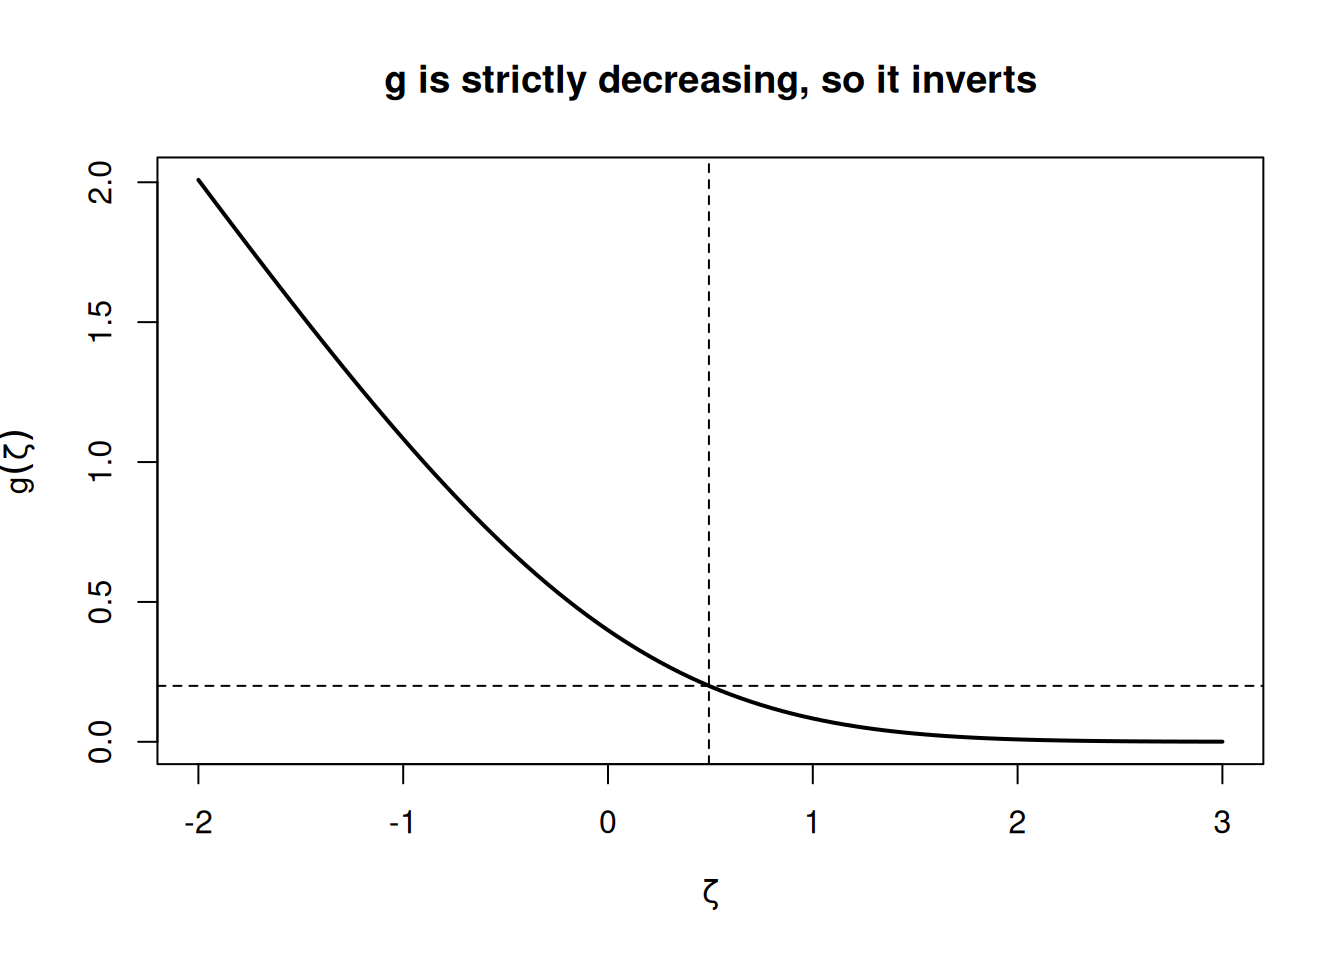

In [ ]:
g     <- function(z) dnorm(z) - z * pnorm(z, lower.tail = FALSE)
g_inv <- function(k) uniroot(function(z) g(z) - k, c(-10, 10))$root

curve(g, -2, 3, lwd = 2, xlab = expression(zeta), ylab = expression(g(zeta)),
      main = "g is strictly decreasing, so it inverts")
abline(h = 0.2, lty = 2); abline(v = g_inv(0.2), lty = 2)


In [ ]:
c(g_of_0 = g(0), zeta_when_cost_is_0.2 = g_inv(0.2))


               g_of_0 zeta_when_cost_is_0.2 
            0.3989423             0.4928911 

## 3. Weitzman’s three rules

With reservation values in hand, optimal behaviour is:

1.  **Selection.** Inspect in decreasing order of $z_j$.
2.  **Stopping.** Stop when the best prize in hand exceeds the highest $z$ among the unopened boxes.
3.  **Choice.** Take the best prize you have opened.

Everything we do from here is the statistics of these three rules.

## 4. The model we will estimate

Consumer $i$ faces $J$ alternatives.

$$
\underbrace{\delta_{ij} = \mathbf{x}_{ij}'\boldsymbol\beta + \eta_{ij}}_{\text{known before searching}},
\qquad
\underbrace{u_{ij} = \delta_{ij} + \varepsilon_{ij}}_{\text{learned by searching}}
$$

with $\eta_{ij}\sim N(0,1)$ and $\varepsilon_{ij}\sim N(0,1)$, and a **constant, known-form search cost** $c$. We start with both variances fixed at one; §11.2 takes up estimating the second.

> **Why we need $\eta$**
>
> Without $\eta$, $\delta_{ij}$ is a deterministic function of $\mathbf{x}_{ij}$, so the search order is deterministic too. Any observed order that does not match the ordering of $\mathbf{x}_{ij}'\boldsymbol\beta$ would have probability exactly zero, and the likelihood would be degenerate. **Reservation values must carry a stochastic component** or the model cannot rationalize observed search orders ([Ursu et al. 2024](#ref-Ursu_Seiler_Honka_2024)).

Note a useful simplification: with $c$ constant and $\sigma=1$, every alternative has the *same* $\zeta$. So $z_{ij} = \delta_{ij} + \zeta$ is a constant shift, and

$$
\textbf{ordering by } z \;=\; \textbf{ordering by } \delta .
$$

Search order reveals the ordering of pre-search utilities. The *number* of searches is what speaks to $c$. Keep that distinction in mind — it is the whole of the identification argument in §10.

## 5. Ten consumers

In [ ]:
sim <- function(N, J, beta, cost, seed = 1) {
  set.seed(seed)
  d <- data.frame(id = rep(1:N, each = J), alt = rep(1:J, N),
                  x1 = rnorm(N * J), x2 = rnorm(N * J))
  d$eta   <- rnorm(N * J)
  d$eps   <- rnorm(N * J)
  d$delta <- d$x1 * beta[1] + d$x2 * beta[2] + d$eta
  d$u     <- d$delta + d$eps
  zeta    <- g_inv(cost)
  d$z     <- d$delta + zeta

  searched <- vector("list", N); choice <- integer(N)
  for (i in 1:N) {
    r   <- d[d$id == i, ]
    ord <- order(r$z, decreasing = TRUE)   # rule 1: search in decreasing z
    K <- 1L; best <- r$u[ord[1]]
    while (K < J && best < r$z[ord[K + 1L]]) {   # rule 2: stop when best >= next z
      K <- K + 1L; best <- max(best, r$u[ord[K]])
    }
    S <- ord[1:K]
    searched[[i]] <- S
    choice[i] <- S[which.max(r$u[S])]      # rule 3: buy the best inspected
  }
  list(d = d, S = searched, y = choice, zeta = zeta,
       N = N, J = J, beta = beta, cost = cost)
}

dat <- sim(N = 10, J = 3, beta = c(1.0, -0.5), cost = 0.2, seed = 7)


What an analyst actually observes — the covariates, the ordered inspection sequence, and the purchase:

In [ ]:
obs <- data.frame(
  consumer = 1:dat$N,
  searched = sapply(dat$S, paste, collapse = " > "),
  n_searched = sapply(dat$S, length),
  bought = dat$y)
knitr::kable(obs)


    consumer searched        n_searched   bought
  ---------- ------------- ------------ --------
           1 1                        1        1
           2 3 \> 1                   2        1
           3 2 \> 3 \> 1              3        1
           4 1 \> 3                   2        3
           5 1                        1        1
           6 1 \> 3                   2        3
           7 2                        1        2
           8 2                        1        2
           9 3 \> 1 \> 2              3        2
          10 3                        1        3


Look at consumer 1. She opened alternative 1 and stopped. That single row says three things: $z_1$ was the highest of the three; whatever she found was good enough to beat both remaining reservation values; and she bought it. Two inequalities and a choice, from one consumer.

Consumer 3 opened all three. That says her first two draws were *disappointing* — each time, the best in hand stayed below the next reservation value.

> **The data you never see**
>
> $\eta$ and $\varepsilon$ are hidden, and $\varepsilon$ is only *realized* for alternatives she opened. Nothing in the data reveals the match value of an alternative she never inspected. That is the whole estimation problem.

## 6. The likelihood

For consumer $i$ with ordered search set $S = (s_1,\dots,s_K)$, unsearched set $\bar S$, and purchase $y$, the four conditions are:

| condition | inequality |
|------------------------------------|------------------------------------|
| **selection** | $z_{s_1} \ge z_{s_2} \ge \dots \ge z_{s_K} \ge \max_{l \in \bar S} z_l$ |
| **continuation** | $\max_{h<k} u_{s_h} < z_{s_k}$ for $k = 2,\dots,K$ |
| **stopping** | $\max_{h \le K} u_{s_h} \ge \max_{l \in \bar S} z_l$ |
| **choice** | $u_y \ge u_{s_h}$ for all $h \le K$ |

and the contribution to the likelihood is the probability that all hold:

$$
\Pr_i(\boldsymbol\beta, c) = \int \mathbb{1}\{\text{all four}\}\; dF(\boldsymbol\eta)\, dF(\boldsymbol\varepsilon).
$$

**This integral has no closed form.** It is a probability over a region of $\mathbb{R}^{2J}$ carved out by inequalities that mix $\eta$ (through both $z$ and $u$) and $\varepsilon$ (through $u$ only). Unlike probit, the region is not an orthant in any convenient basis.

So we simulate it.

## 7. First attempt: the crude frequency simulator

The obvious estimator. Draw $\boldsymbol\eta$ and $\boldsymbol\varepsilon$, check whether all four conditions hold, and count.

In [ ]:
loglik_cfs <- function(par, dat, R = 2000, seed = 99) {
  set.seed(seed)
  b <- par[1:2]; cost <- exp(par[3])
  zeta <- g_inv(cost); N <- dat$N; J <- dat$J
  ll <- 0
  for (i in 1:N) {
    r  <- dat$d[dat$d$id == i, ]
    xb <- r$x1 * b[1] + r$x2 * b[2]
    S  <- dat$S[[i]]; K <- length(S); U <- setdiff(1:J, S); y <- dat$y[i]
    hit <- 0
    for (rep in 1:R) {
      delta <- xb + rnorm(J)
      u     <- delta + rnorm(J)
      z     <- delta + zeta
      ok <- TRUE
      if (K >= 2) for (k in 1:(K - 1)) if (z[S[k]] < z[S[k + 1]]) { ok <- FALSE; break }
      if (ok && length(U)) if (z[S[K]] < max(z[U])) ok <- FALSE
      if (ok && K >= 2) for (k in 2:K)
        if (max(u[S[1:(k - 1)]]) >= z[S[k]]) { ok <- FALSE; break }
      if (ok && length(U)) if (max(u[S]) < max(z[U])) ok <- FALSE
      if (ok) if (u[y] < max(u[S])) ok <- FALSE
      hit <- hit + ok
    }
    ll <- ll + log(max(hit / R, 1e-10))
  }
  ll
}

loglik_cfs(c(1.0, -0.5, log(0.2)), dat)


[1] -23.63405

It works, and it is unbiased for each probability. **It is also unusable for optimization**, and the reason is worth seeing rather than being told.

Hold the draws fixed and vary $\beta_1$ on a fine grid, for a single consumer:

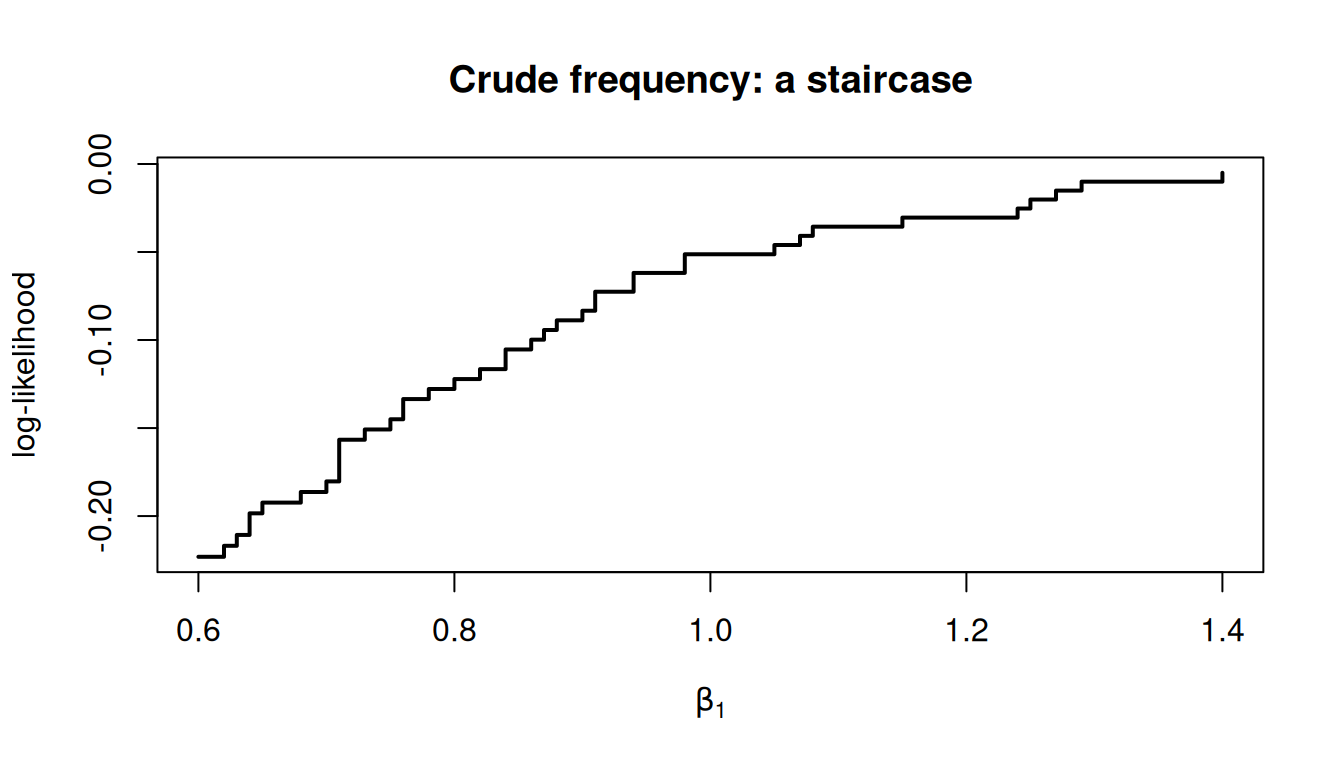

In [ ]:
one <- dat; one$N <- 1
one$d <- dat$d[dat$d$id == 1, ]; one$S <- dat$S[1]; one$y <- dat$y[1]

grid <- seq(0.6, 1.4, by = 0.01)
cf   <- sapply(grid, function(b) loglik_cfs(c(b, -0.5, log(0.2)), one, R = 200))

plot(grid, cf, type = "s", lwd = 2, xlab = expression(beta[1]),
     ylab = "log-likelihood", main = "Crude frequency: a staircase")


In [ ]:
c(distinct_values = length(unique(round(cf, 8))),
  grid_points     = length(grid),
  longest_flat_run = max(rle(round(cf, 8))$lengths))


 distinct_values      grid_points longest_flat_run 
              31               81               11 

The estimator is a **step function**. Its derivative is zero almost everywhere and undefined at the jumps, so gradient-based optimizers have nothing to follow. The indicator either fires or it does not; small parameter changes move no draw across a boundary until suddenly one does.

## 8. The fix: smooth the indicator

Replace the hard indicator with a smooth approximation. Write each condition as a margin $\nu \ge 0$ that should be non-negative, and use a logit kernel ([Yavorsky et al. 2021](#ref-Yavorsky_2021)):

$$
\tilde{\mathbb{1}} \;=\; \Big(1 + \textstyle\sum_m e^{-\lambda \nu_m}\Big)^{-1}.
$$

When every margin is comfortably positive this is near 1; when any is negative it is near 0; and in between it varies **smoothly** with the parameters. The scale $\lambda$ controls the trade-off: larger is a better approximation to the indicator but a less smooth objective.

> **Common random numbers**
>
> Both likelihood functions call `set.seed(seed)` on entry, so **the same draws are reused at every parameter value**. This is not incidental. If fresh draws were taken at each evaluation, the objective would jitter by the simulation error from one call to the next, and the optimizer would be climbing a surface that moves under it — jagged again, for a different reason than the staircase. Holding the draws fixed makes the simulated objective a deterministic function of the parameters. It is standard practice in simulation estimation and it is worth naming, because forgetting it produces a failure that looks like a modelling problem and is not.

In [ ]:
loglik_smooth <- function(par, dat, R = 500, lambda = 8, seed = 99) {
  set.seed(seed)
  b <- par[1:2]; cost <- exp(par[3])
  zeta <- tryCatch(g_inv(cost), error = function(e) NA)
  if (is.na(zeta)) return(-1e10)
  N <- dat$N; J <- dat$J
  ll <- 0
  for (i in 1:N) {
    r  <- dat$d[dat$d$id == i, ]
    xb <- r$x1 * b[1] + r$x2 * b[2]
    S  <- dat$S[[i]]; K <- length(S); U <- setdiff(1:J, S); y <- dat$y[i]
    acc <- numeric(R)
    for (rep in 1:R) {
      delta <- xb + rnorm(J)
      u     <- delta + rnorm(J)
      z     <- delta + zeta
      pen <- 0
      # selection
      if (K >= 2) for (k in 1:(K - 1)) pen <- pen + exp(-lambda * (z[S[k]] - z[S[k + 1]]))
      if (length(U)) for (l in U)      pen <- pen + exp(-lambda * (z[S[K]] - z[l]))
      # continuation
      if (K >= 2) for (k in 2:K)       pen <- pen + exp(-lambda * (z[S[k]] - max(u[S[1:(k - 1)]])))
      # stopping
      if (length(U))                   pen <- pen + exp(-lambda * (max(u[S]) - max(z[U])))
      # choice
      for (h in S) if (h != y)         pen <- pen + exp(-lambda * (u[y] - u[h]))
      acc[rep] <- 1 / (1 + pen)
    }
    ll <- ll + log(max(mean(acc), 1e-300))
  }
  ll
}


The same slice, now smooth:

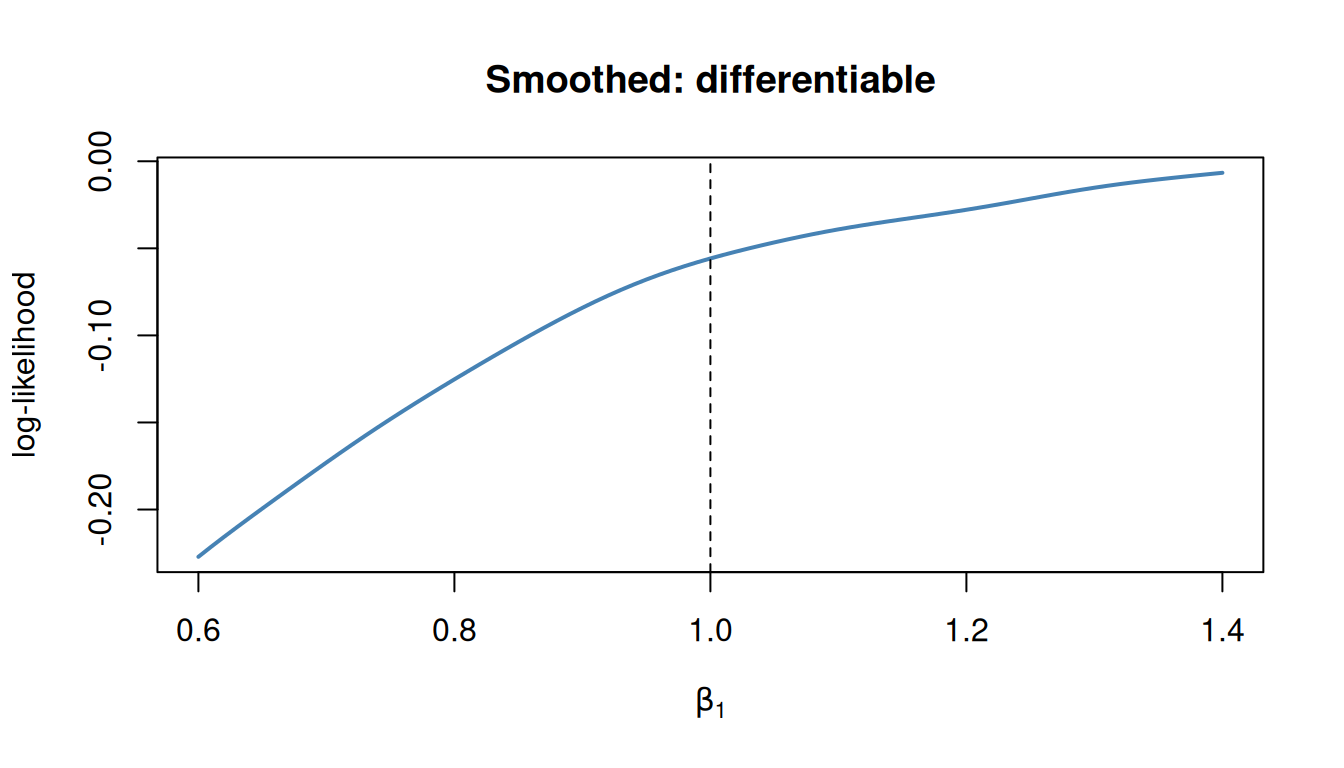

In [ ]:
sm <- sapply(grid, function(b) loglik_smooth(c(b, -0.5, log(0.2)), one, R = 200))
plot(grid, sm, type = "l", lwd = 2, col = "steelblue", xlab = expression(beta[1]),
     ylab = "log-likelihood", main = "Smoothed: differentiable")
abline(v = 1.0, lty = 2)


In [ ]:
c(distinct_values = length(unique(round(sm, 8))),
  longest_flat_run = max(rle(round(sm, 8))$lengths))


 distinct_values longest_flat_run 
              81                1 

Every grid point gives a distinct value. There is now a gradient to follow.

> **What smoothing costs**
>
> The smoothed estimator is **biased** for any finite $\lambda$: it is only asymptotically unbiased as $\lambda \to \infty$. But large $\lambda$ restores the staircase. You are choosing a point on a bias–smoothness trade-off, and $\lambda$ is a tuning constant you must justify — see §9.1 for how much it can matter, and §11.5 for estimators that avoid it.

## 9. How much does $\lambda$ matter?

Before trusting any estimate, find out what the tuning constant is doing. Fit the same 600-consumer dataset at a range of $\lambda$ and compare.

In [ ]:
for (lam in c(2, 4, 8, 16, 30)) {
  f <- optim(c(0, 0, log(0.5)),
             function(p) -loglik_smooth(p, big, R = 300, lambda = lam),
             method = "BFGS", control = list(maxit = 200))
  cat(sprintf("lambda %5.0f   beta1 %6.3f   beta2 %6.3f   cost %6.3f\n",
              lam, f$par[1], f$par[2], exp(f$par[3])))
}


This takes several minutes, so the results are tabulated rather than run inline. Truth is $\beta_1 = 1.0$, $\beta_2 = -0.5$, $c = 0.2$.

| $\lambda$ | $\hat\beta_1$ | $\hat\beta_2$ | $\hat c$  |
|-----------|---------------|---------------|-----------|
| 2         | 1.024         | −0.508        | **0.448** |
| 4         | 0.986         | −0.494        | 0.299     |
| 8         | 0.989         | −0.495        | **0.220** |
| 16        | 0.823         | −0.453        | 0.194     |
| 30        | 0.744         | −0.401        | 0.203     |

> **Read this table before believing any single fit**
>
> The search cost moves by a factor of **2.3** across this range, from 0.448 to 0.194. There is no value of $\lambda$ at which everything is simultaneously best, and the failure modes at the two ends are different.
>
> At **small $\lambda$** the kernel is a poor approximation to the indicator: conditions that are in fact violated still contribute, the likelihood is too generous, and $\hat c$ is badly overstated. At **large $\lambda$** the approximation is excellent but the staircase returns — the objective is nearly flat between jumps, the optimizer stalls, and $\hat\beta$ decays toward its starting value.
>
> The preference parameters are the more robust of the two, which is the same asymmetry §10 explains. But the search cost is only well estimated in a middle range, and nothing in the estimator tells you where that range is.
>
> **The practical rule: never report a search-cost estimate from a single $\lambda$.** Report the sensitivity, or use an estimator that has no tuning constant (§11.5).

## 9.1 Does it recover the truth?

Ten consumers is too few to estimate three parameters. Six hundred is enough to see recovery.

In [ ]:
big <- sim(N = 600, J = 3, beta = c(1.0, -0.5), cost = 0.2, seed = 21)
prop.table(table(sapply(big$S, length)))



         1          2          3 
0.68666667 0.26166667 0.05166667 

In [ ]:
fit <- optim(c(0, 0, log(0.5)),
             function(p) -loglik_smooth(p, big, R = 300, lambda = 8),
             method = "BFGS", control = list(maxit = 200))

data.frame(parameter = c("beta1", "beta2", "search cost"),
           truth     = c(1.0, -0.5, 0.2),
           estimate  = c(fit$par[1], fit$par[2], exp(fit$par[3])))


    parameter truth   estimate
1       beta1   1.0  0.9885493
2       beta2  -0.5 -0.4947429
3 search cost   0.2  0.2204155

Both preference parameters and the search cost are recovered. Note that we estimated $\log c$ rather than $c$, so that the optimizer cannot propose a negative cost.

> **What kind of estimator this is**
>
> This is **simulated maximum likelihood**, and its asymptotics are not those of MLE. The simulator is unbiased for each *probability*, but the likelihood uses the *log* of that probability, and by Jensen’s inequality $\mathbb{E}[\log \hat p]
> < \log p$. The bias is of order $1/R$ and — this is the part that catches people — **it does not vanish as $N \to \infty$ at fixed $R$**. Consistency requires $R \to \infty$ along with $N$, at a rate fast enough that $\sqrt{N}/R \to 0$.
>
> Two practical consequences. Adding consumers does not rescue an estimate computed with too few draws. And the smoothing bias of the previous section is a *second*, separate bias that does not vanish as $R$ grows either — only as $\lambda$ grows, which trades against smoothness. A simulated search-model estimate carries both.

## 10. What identifies what

Worth pausing on, because it is not obvious and it drives every design decision in applied work.

**Preferences ($\boldsymbol\beta$) are identified twice over.** They govern the purchase among inspected alternatives — the same margin a choice model uses — and they govern the *order* of inspection, since $z$ and $\delta$ order identically. Two independent sources of information.

**The search cost is identified by how much people search, and by almost nothing else.** Raise $c$ and reservation values fall, so consumers stop sooner. The distribution of $K$ across consumers is the moment doing the work.

This asymmetry has consequences you will meet immediately in practice:

- $\boldsymbol\beta$ is estimated precisely; $c$ is not.
- If most consumers inspect exactly one alternative, there is very little variation in $K$ and the search cost is weakly identified.
- Anything that shifts search costs *exogenously and across alternatives* is extremely valuable, because it produces variation in $K$ that is not confounded with preference. This is why Ursu ([2018](#ref-Ursu_2018)) makes so much of randomized rankings, and why Yavorsky et al. ([2021](#ref-Yavorsky_2021)) builds an argument around driving distance.

## 11. Extensions

Each of these is one step from what you have already written.

One natural-seeming extension is deliberately absent. **Correlated match values** — letting $\varepsilon_{ij}$ covary across $j$ — is not an extension of this framework but a departure from it. It violates assumption 3 of §2, so reservation values are no longer computable in isolation and Weitzman’s rules are no longer optimal. You cannot add a covariance to `sim()` and re-estimate; you would have to solve the dynamic program the reservation value was introduced to avoid.

### 11.1 Search costs that depend on covariates

Replace the constant with $c_{ij} = \exp(\mathbf{w}_{ij}'\boldsymbol\gamma)$. Positivity comes free from the exponential. In the code, `zeta` stops being a scalar and becomes a vector — call `g_inv` per alternative.

The consequence is more interesting than the code change. With a constant cost, $\zeta$ was common across alternatives, so search order was determined entirely by $\delta$. Now alternatives with different costs have different $\zeta$, and **search order is no longer the same as preference order**. An alternative may be inspected early because it is cheap to inspect rather than because it is attractive.

That is a loss of a clean identification argument, but order is not the only margin. Consider two alternatives with the same reservation value: A is attractive but expensive to inspect, B is mediocre but cheap. They are opened first equally often, because order responds only to $z$. Once A is opened, though, its cost is sunk while its high realized utility is not — so A stops search more often than B does. **Stopping rates after inspection separate $\delta$ from $c$ where order alone cannot** ([Ursu et al. 2024](#ref-Ursu_Seiler_Honka_2024)).

So no exclusion restriction is needed *in principle*, which is why $\mathbf{w}$ and $\mathbf{x}$ may overlap and why you can ask whether a characteristic shifts utility, search cost, or both. But that argument leans entirely on the assumed shock distributions. This is the same in-principle-versus-credible distinction as §11.2, and it has the same resolution: if $\mathbf{w}$ contains something randomized, it moves search order without moving preference, and you no longer have to lean on functional form.

### 11.2 Estimating the match-value standard deviation

We fixed $\sigma_\varepsilon = 1$. Almost all of the literature does the same. Why?

Look again at $g(\zeta) = c/\sigma$ and $z = \delta + \zeta\sigma$. The search cost and the match-value spread enter through the *same channel*, and they push in opposite directions: a large $\sigma$ makes searching attractive, a large $c$ makes it unattractive. Both change $K$.

They are separately identified, but by a thinner argument than it first appears. Note that $\zeta$ solves $g(\zeta) = c/\sigma$ and so depends on the **ratio** alone: how *much* people search speaks only to $c/\sigma$. What breaks the tie is that $\sigma$ appears twice more, and not only in that ratio. It multiplies $\zeta$ in $z = \delta + \zeta\sigma$, and it scales $\varepsilon$ inside $u$. Because we normalized $\sigma_\eta = 1$, search *order* responds to $\boldsymbol\beta$ while the purchase among inspected alternatives responds to $\boldsymbol\beta/\sigma_\varepsilon$ — and the relative sensitivity of those two margins is what pins $\sigma_\varepsilon$ down.

That is real identification, but it runs entirely through assumed distributions and a normalization, so it is weak. In practice the two are nearly collinear: Yavorsky et al. ([2021](#ref-Yavorsky_2021)) report a correlation of $0.95$ between $\log\sigma$ and the search-cost intercept even with 6,511 consumers.

What breaks the tie is an *exogenous, alternative-specific* search-cost shifter. With one in hand, $\boldsymbol\gamma$ is identified from how search responds to $\mathbf{w}$, and $\sigma$ is then identified separately from the level of search. Yavorsky et al. ([2021](#ref-Yavorsky_2021)) estimate $\sigma = 8.16$ where the literature had been imposing 1, with large consequences for what search costs are worth in money.

The exercise to run: fix $\sigma$ at 1 in your estimation while simulating data with $\sigma = 3$, and watch the search-cost estimate absorb the misspecification.

### 11.3 An outside option, and zero searches

We assumed the first search always happens. Real data include consumers who inspect nothing.

Add an alternative $j=0$ whose utility $u_0$ is known from the outset and needs no search. Then $u_0$ joins the running maximum **everywhere it appears** in §6, not only at the first step:

- continuation becomes $\max\left(u_0,\ \max_{h<k} u_{s_h}\right) < z_{s_k}$
- stopping becomes $\max\left(u_0,\ \max_{h \le K} u_{s_h}\right) \ge \max_{l \in \bar S} z_l$
- choice now ranges over $S \cup \{0\}$, so $y = 0$ — searched, bought nothing — is an outcome the likelihood must be able to produce

Because alternatives are opened in decreasing $z$, the running maximum is non-decreasing, so the *binding* new restriction is $u_0 < z_{s_K}$ at the last search; the condition at $k=1$ is implied by it. And $K=0$ is simply continuation failing at the first step: $u_0 \ge \max_j z_j$.

Getting this wrong is easy and silent. Patch only the $k=1$ guard, leave the stopping and choice lines of `loglik_cfs` and `loglik_smooth` untouched, and the estimator still runs and still converges — on the wrong model.

This matters more than it looks. Conditioning on having searched selects the sample on an outcome the model is trying to explain. Papers that do it handle the problem in one of two ways: assume the first search is free, which makes searching at least once a probability-one event ([Honka 2014](#ref-Honka_2014)), or write a partial likelihood conditional on having searched while keeping every search costly. Observing the non-searchers, as we do here, removes the need for either.

### 11.4 Heterogeneity

Let $\boldsymbol\beta_i$ and $\boldsymbol\gamma_i$ vary across consumers, with $\boldsymbol\theta_i \sim N(\bar{\boldsymbol\theta}, \Sigma)$.

The obstacle is that identifying individual-level parameters requires observing each consumer **more than once**. With one search spell per consumer, you can estimate the distribution’s parameters but not each consumer’s position in it. Morozov et al. ([2021](#ref-Morozov_2021)) prove nonparametric identification from panel search data, with the caveat that the argument takes sessions per consumer to infinity — with a mean of five they report hyperparameters only.

Two estimation routes. Simulated maximum likelihood integrates over the heterogeneity distribution, multiplying cost by the number of mixing draws. Hierarchical Bayes does not: each consumer sits at their own $\boldsymbol\theta_i$ and the mixing-draw multiplier disappears. For search models, **HB is usually the cheaper route**, which is the reverse of the folklore.

### 11.5 Better simulators

Kernel smoothing is general and easy to write, which is why it dominated the field for a decade. Its costs are the tuning constant $\lambda$, the bias for finite $\lambda$, and high simulation variance.

Three alternatives, roughly in order of how much machinery they require:

- **Importance sampling** ([Ackerberg 2009](#ref-Ackerberg_2009)) reuses draws across parameter values, so the likelihood becomes smooth in the parameters without a kernel.
- **GHK-type simulators** exploit the fact that, *conditional on the observed purchase*, the four conditions become a conjunction of linear inequalities — an orthant probability, which GHK evaluates far more accurately than accept–reject.
- **Reformulating what is random** ([Chung et al. 2024](#ref-Chung_2025)) makes the search *cost* stochastic rather than the pre-search taste shock, which turns the search probabilities into recursive truncated draws and reports speedups of one to two orders of magnitude.

Ursu et al. ([2024](#ref-Ursu_Seiler_Honka_2024)) compare these systematically and is the right next thing to read.

### 11.6 The effective-value representation

One result you will meet immediately in the literature and which we have not used. Armstrong ([2017](#ref-Armstrong_2017)) and Choi et al. ([2018](#ref-Choi_2018)) show that the *purchase* probability of the sequential search model is exactly that of a static discrete choice over the **effective value**

$$
w_{ij} = \min\left(u_{ij},\ z_{ij}\right).
$$

In our notation $z = \delta + \zeta$ and $u = \delta + \varepsilon$ share $\delta$, so $w_{ij} = \delta_{ij} + \min(\varepsilon_{ij}, \zeta)$ — a choice model whose error is a truncated post-search shock. This is the standard route to market shares, welfare, and elasticities, because it turns a search model into something with the algebra of a choice model.

Two cautions. It requires that every search be costly and that an outside option always be available, neither of which holds for the estimator you just wrote — so §11.3 comes first. And it collapses the *purchase* probability only, not the joint probability of an ordered search sequence, which is what our likelihood in §6 actually targets. It is a tool for what you do with estimates, not a replacement for how you obtain them.

## 12. Exercises

1.  Set $\beta = 0$ and re-simulate. What does the distribution of $K$ look like, and can you still recover $c$?
2.  Drive $c \to 0$. Verify that everyone inspects everything and the model collapses to a standard choice model over fully realized utilities. This is the sense in which conjoint is the zero-search-cost special case.
3.  Vary $\lambda$ over $\{2, 8, 30\}$ and plot the objective. Where does the staircase reappear?
4.  Simulate with $\sigma_\varepsilon = 3$, estimate with it fixed at 1, and report the bias in $\hat c$. Then add a randomized cost shifter and estimate $\sigma$ freely.
5.  Add an outside option and allow $K=0$. How much does the search-cost estimate move when the zero-search consumers are included rather than dropped?

Ackerberg, Daniel A. 2009. “A New Use of Importance Sampling to Reduce Computational Burden in Simulation Estimation.” *Quantitative Marketing and Economics* 7 (4): 343–76. <https://doi.org/10.1007/s11129-009-9074-z>.

Armstrong, Mark. 2017. “Ordered Consumer Search.” *Journal of the European Economic Association* 15 (5): 989–1024. <https://doi.org/10.1093/jeea/jvx017>.

Choi, Michael, Anovia Yifan Dai, and Kyungmin Kim. 2018. “Consumer Search and Price Competition.” *Econometrica* 86 (4): 1257–81. <https://doi.org/10.3982/ecta14837>.

Chung, Jae Hyen, Pradeep Chintagunta, and Sanjog Misra. 2024. “Simulated Maximum Likelihood Estimation of the Sequential Search Model.” *Quantitative Marketing and Economics* 23 (1): 105–64. <https://doi.org/10.1007/s11129-024-09281-4>.

Honka, Elisabeth. 2014. “Quantifying Search and Switching Costs in the US Auto Insurance Industry.” *The RAND Journal of Economics* 45 (4): 847–84. <https://doi.org/10.1111/1756-2171.12073>.

Morozov, Ilya, Stephan Seiler, Xiaojing Dong, and Liwen Hou. 2021. “Estimation of Preference Heterogeneity in Markets with Costly Search.” *Marketing Science* 40 (5): 871–99. <https://doi.org/10.1287/mksc.2021.1287>.

Ursu, Raluca M. 2018. “The Power of Rankings: Quantifying the Effect of Rankings on Online Consumer Search and Purchase Decisions.” *Marketing Science* 37 (4): 530–52. <https://doi.org/10.1287/mksc.2017.1072>.

Ursu, Raluca, Stephan Seiler, and Elisabeth Honka. 2024. “The Sequential Search Model: A Framework for Empirical Research.” *Quantitative Marketing and Economics* 23 (1): 165–213. <https://doi.org/10.1007/s11129-024-09291-2>.

Weitzman, Martin L. 1979. “Optimal Search for the Best Alternative.” *Econometrica* 47 (3): 641–54. <https://doi.org/10.2307/1910412>.

Yavorsky, Dan, Elisabeth Honka, and Keith Chen. 2021. “Consumer Search in the U.S. Auto Industry: The Role of Dealership Visits.” *Quantitative Marketing and Economics* 19 (1): 1–52. <https://doi.org/10.1007/s11129-020-09229-4>.